## Veri Ön İşleme (Data Preprocessing)


Amaç: Veriyi makine öğrenmesi modeli için uygun hale getirmek. İçerik:
- Aykırı Değerler (Outliers)
- Kategorik Veriler (Categorical Data)
- Veri Dönüşümleri (Data Transformation)
- Veri Tutarlılığı ve Yinelenen Kayıtlar (Data Consistency)
- Veri Bölme (Train/Test Split)
- Mini Proje

### Aykırı Değerler (Outliers)
Amaç: Veri setinde diğer gözlemlerden çok farklı olan, modelin öğrenme sürecini bozabilecek uç değerleri tespit etmek ve doğru şekilde yönetmek.
Aykırı değerleri yönetemezsek:
- Regresyon modellerinde hatalı eğimler oluşabilir
- Ortalama ve varyans değerleri bozulabilir
- Model gürültüye duyarlı hale gelir.

Aykırı değer (outlier), bir veri setindeki diğer gözlemlerden istatistiksel olarak önemli ölçüde farklı olan gözlemlerdir. Genelde veri toplama hatalarından, ölçüm cihazı hatalarından veya gerçekten sıra dışı olaylardan kaynaklanır.

Gerçek hayat örneği:
Mesela bir sigorta şirketi araç hasar kayıtları 10.000 - 50.000 arasında olsun. Ama birkaç kayıt 1.000.000 TL gibi uç değerlere sahip.
- lüks araç kazası
- yanlışlıkla 1 sıfır fazla atılmış olabilir
Sonuç olarak bunu tespit edip anlamdırmak lazım.

İçerik planı:
- Aykırı değerlerin görselleştirilmesi (boxplot)
- IQR (Interquartile Range) yöntemiyle outlier tespiti
- Aykırı değerleri temizleme
- Sonucun kontrol edilmesi

In [ ]:
"""
Veri seti oluştur: Sigorta hasar bedelleri ile ilgili veri seti oluştur
"""

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#örnek veri seti oluşturma
np.random.seed(42)

#normal dağılımlı bir hasar verisi ortalama = 50000, std =8000, adet = 200
hasar = np.random.normal(50000,8000,200)

# aykırı değerleri ekleyelim
hasar = np.append(hasar, [150000,170000,200000])

df = pd.DataFrame({"hasar":hasar})
df.head()

,hasar
0,53973.713224
1,48893.885591
2,55181.508305
3,62184.238851
4,48126.773002


### Aykırı Değerlerin Görselleştirilmesi

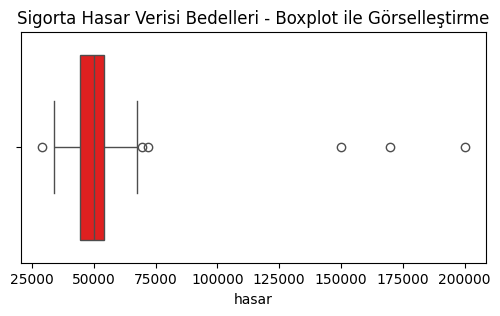

In [ ]:
plt.figure(figsize=(6,3))
sns.boxplot(x=df["hasar"],color="red")
plt.title("Sigorta Hasar Verisi Bedelleri - Boxplot ile Görselleştirme")
plt.show()

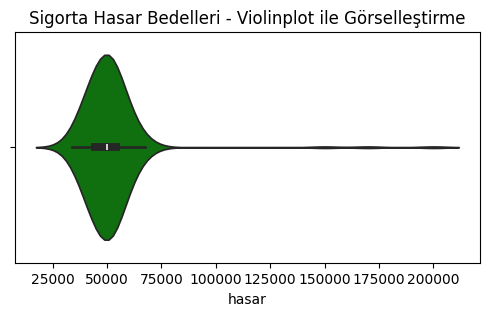

In [ ]:
plt.figure(figsize=(6,3))
sns.violinplot(x=df["hasar"],color="green")
plt.title("Sigorta Hasar Bedelleri - Violinplot ile Görselleştirme")
plt.show()

### IQR Yöntemi ile Outlier Tespiti

In [ ]:
#çeyrek değerlerin hesaplanması
Q1 = df["hasar"].quantile(0.25) #birinci çeyrek
Q3 = df["hasar"].quantile(0.75) #üçüncü çeyrek

IQR = Q3 - Q1
print(IQR)

9786.317698634826


In [ ]:
alt_sinir = Q1 - 1.5*IQR
ust_sinir = Q3 + 1.5*IQR
print(alt_sinir)
print(ust_sinir)

29792.21219022439
68937.48298476369


In [ ]:
#aykırı değerleri tespit et
aykiri_degerler = df[(df["hasar"] < alt_sinir) | (df["hasar"] > ust_sinir) ]
print("Aykırı değer sayısı:",len(aykiri_degerler))
print(aykiri_degerler)

Aykırı değer sayısı: 6
             hasar
74    29042.039167
113   69705.936900
179   71761.353333
200  150000.000000
201  170000.000000
202  200000.000000


### Aykırı Değerlerin Temizlenmesi

In [ ]:
# sınırlandırma
df["hasar_sinirlandirilmis"] = np.where(df["hasar"]>ust_sinir,ust_sinir,np.where(df["hasar"]<alt_sinir,alt_sinir,df["hasar"]))

df

,hasar,hasar_sinirlandirilmis
0,53973.713224,53973.713224
1,48893.885591,48893.885591
2,55181.508305,55181.508305
3,62184.238851,62184.238851
4,48126.773002,48126.773002
...,...,...
198,50465.669748,50465.669748
199,40856.237617,40856.237617
200,150000.000000,68937.482985
201,170000.000000,68937.482985


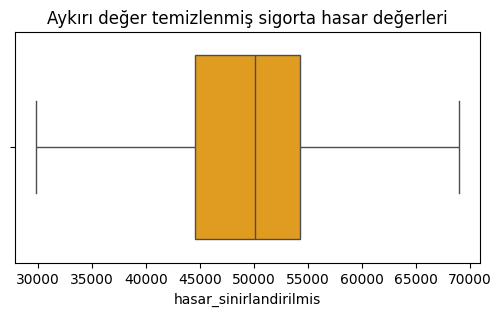

In [ ]:
# yeni dağılımı görselleştirme
plt.figure(figsize=(6,3))
sns.boxplot(x=df["hasar_sinirlandirilmis"],color="orange")
plt.title("Aykırı değer temizlenmiş sigorta hasar değerleri")
plt.show()

### Sonuç Kontrolü

In [ ]:
print(f"Temizleme öncesi veri sayısı: {len(df)}")
print(f"Aykırı değer sayısı: {len(aykiri_degerler)}")
print(f"Temizleme sonrası minimum hasar kaydı değeri: {df["hasar_sinirlandirilmis"].min()}")
print(f"Temizleme sonrası minimum hasar kaydı değeri: {df["hasar_sinirlandirilmis"].max()}")

Temizleme öncesi veri sayısı: 203
Aykırı değer sayısı: 6
Temizleme sonrası minimum hasar kaydı değeri: 29792.21219022439
Temizleme sonrası minimum hasar kaydı değeri: 68937.48298476369


## Kategorik Veriler (Categorical Data)
Veri setlerinde metinsel veya sınıf bazlı sütunları sayısal değerlere dönüştürmemiz gerekiyor. Makine öğrenmesi algoritmaları (regresyon, karar ağaçları, sinir ağları vb.) yalnızca sayısal veriler ile çalışabilirler. Bu nedenle kategorik verileri doğru şekilde kodlamak modelin başarımını doğrudan etkileyecektir.

Kategorik veri, sınırlı sayıda benzersiz değer alan değişkenlerdir. Örneğin:
- Cinsiyet -> erkek,kadın
- Üyelik türü -> standart, premium, vip
- Şehir -> Ankara, İzmir, İstanbul, Konya
Bu tür veriler string (metin) formundadır ve makine öğrenmesi modelimize girmeden önce sayısal forma dönüştürülmek zorundadır.

Gerçek hayat örneği:
Bir e-ticaret şirketi müşteri verilerini analiz ediyor:
- Cinsiyet -> erkek, kadın
- Ülke -> Türkiye, İngiltere
- Eğitim seviyesi -> lisans, önlisans, doktora

İçerik Planı:
1. Label Encoding
2. One-Hot Encoding
3. Dummy variable tuzağı önleme
4. Kodlanmış veriyi dataframede birleştirme

In [1]:
"""
Veri seti oluşturma: E-ticaret müşteri verileri
 cinsiyet
 üyelik türü
 şehir

Amaç: metinsel değişkenleri modele uygun sayısal değerlere dönüştürmek
"""

import pandas as pd

#örnek veri seti
data = {
    "cinsiyet": ["erkek","kadın","kadın","erkek","kadın"],
    "uyelik_turu": ["standart","premium","vip","premium","standart"],
    "sehir": ["ankara","istanbul","izmir","ankara","izmir"],
    "gelir": [5000,7000,12000,6500,8000]
}

df = pd.DataFrame(data)
df

,cinsiyet,uyelik_turu,sehir,gelir
0,erkek,standart,ankara,5000
1,kadın,premium,istanbul,7000
2,kadın,vip,izmir,12000
3,erkek,premium,ankara,6500
4,kadın,standart,izmir,8000


### Label Encoding (Etiket Kodlama)
Tanım: Her kategorik değere benzersiz bir sayı atanır.
Örneğin:
- Erkek -> 0
- Kadın -> 1
---
- Avantaj: Basit ve hafif bir yöntem.
- Dezavantajı: Sayılar model tarafından sıralı (ordinal) algılanabilir.
- Örneğin: kadın (1) > erkek (0) şeklinde çıkarım yapılabilir.

In [2]:
from sklearn.preprocessing import LabelEncoder

In [3]:
label_encoder = LabelEncoder()

In [5]:
df["cinsiyet_label"] = label_encoder.fit_transform(df["cinsiyet"])
df

,cinsiyet,uyelik_turu,sehir,gelir,cinsiyet_label
0,erkek,standart,ankara,5000,0
1,kadın,premium,istanbul,7000,1
2,kadın,vip,izmir,12000,1
3,erkek,premium,ankara,6500,0
4,kadın,standart,izmir,8000,1


In [6]:
df["uyelik_turu_label"] = label_encoder.fit_transform(df["uyelik_turu"])
df

,cinsiyet,uyelik_turu,sehir,gelir,cinsiyet_label,uyelik_turu_label
0,erkek,standart,ankara,5000,0,1
1,kadın,premium,istanbul,7000,1,0
2,kadın,vip,izmir,12000,1,2
3,erkek,premium,ankara,6500,0,0
4,kadın,standart,izmir,8000,1,1


### One-Hot Encoding
Her kategori için ayrı bir sütun oluşturulur. Eğer değer o kategoriye aitse "1" değilse "0" olarak atanır.

- uyelik_turu: standart, premium, vip
  - üyelik_turu_standart
  - uyelik_turu_premium
  - uyelik_turu_vip

- Avantaj: model kategoriler arasında yanlış hiyerarşi kurmaz.
- Dezavantaj: kategori sayısı fazla olduğunda veri boyutu çok artar.

In [7]:
from sklearn.preprocessing import OneHotEncoder

In [8]:
one_hot_encoder = OneHotEncoder(sparse_output = False)
encoded_array = one_hot_encoder.fit_transform(df[["uyelik_turu"]])
encoded_array

array([[0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.]])

In [10]:
# yeni sütün adlarını alalım
encoded_columns = one_hot_encoder.get_feature_names_out(["uyelik_turu"])


In [11]:
#yeni bir df oluştur
encoded_df = pd.DataFrame(encoded_array, columns = encoded_columns)
encoded_df

,uyelik_turu_premium,uyelik_turu_standart,uyelik_turu_vip
0,0.0,1.0,0.0
1,1.0,0.0,0.0
2,0.0,0.0,1.0
3,1.0,0.0,0.0
4,0.0,1.0,0.0


### Dummy Variable Tuzağı
One-Hot encoding sonrasında tüm sütunlar modele dahil edilirse, sütunlar arasında doğrusal bağımlılık oluşur. Bu durumda bir sütunu çıkarmamız gerekir. Yani N kategoriden N-1 kategoriye düşeriz.

In [12]:
encoded_df = encoded_df.drop(columns = ["uyelik_turu_standart"])
encoded_df

,uyelik_turu_premium,uyelik_turu_vip
0,0.0,0.0
1,1.0,0.0
2,0.0,1.0
3,1.0,0.0
4,0.0,0.0


### Kodlanmış veriyi dataframe de birleştirme

In [14]:
df_final = pd.concat([df,encoded_df],axis=1)
df_final

,cinsiyet,uyelik_turu,sehir,gelir,cinsiyet_label,uyelik_turu_label,uyelik_turu_premium,uyelik_turu_vip
0,erkek,standart,ankara,5000,0,1,0.0,0.0
1,kadın,premium,istanbul,7000,1,0,1.0,0.0
2,kadın,vip,izmir,12000,1,2,0.0,1.0
3,erkek,premium,ankara,6500,0,0,1.0,0.0
4,kadın,standart,izmir,8000,1,1,0.0,0.0


In [15]:
df_final.drop(columns=["cinsiyet","uyelik_turu","uyelik_turu_label"])

,sehir,gelir,cinsiyet_label,uyelik_turu_premium,uyelik_turu_vip
0,ankara,5000,0,0.0,0.0
1,istanbul,7000,1,1.0,0.0
2,izmir,12000,1,0.0,1.0
3,ankara,6500,0,1.0,0.0
4,izmir,8000,1,0.0,0.0
